In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fraud-detection')

# Load saved models and scalers
xgb_f = joblib.load('models/xgb_fraud.joblib')
xgb_cc = joblib.load('models/xgb_creditcard.joblib')
scaler_f = joblib.load('models/scaler_fraud.joblib')
scaler_cc = joblib.load('models/scaler_creditcard.joblib')

print("Models loaded!")

Models loaded!


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Fraud_Data
fraud = pd.read_csv('data/processed/fraud_features.csv')
fraud_model = fraud.copy()
cat_cols = ['source', 'browser', 'sex', 'country']
for col in cat_cols:
    le = LabelEncoder()
    fraud_model[col] = le.fit_transform(fraud_model[col].astype(str))

X_fraud = fraud_model.drop(columns=['user_id', 'class'])
y_fraud = fraud_model['class']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud)
X_test_f_scaled = scaler_f.transform(X_test_f)
X_test_f_df = pd.DataFrame(X_test_f_scaled, columns=X_fraud.columns)

# CreditCard
cc = pd.read_csv('data/processed/creditcard_features.csv')
X_cc = cc.drop(columns=['Class'])
y_cc = cc['Class']
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=42, stratify=y_cc)
X_test_cc_scaled = scaler_cc.transform(X_test_cc)
X_test_cc_df = pd.DataFrame(X_test_cc_scaled, columns=X_cc.columns)

print(f"Fraud test set: {X_test_f_df.shape}")
print(f"CreditCard test set: {X_test_cc_df.shape}")

Fraud test set: (30223, 12)
CreditCard test set: (56962, 30)


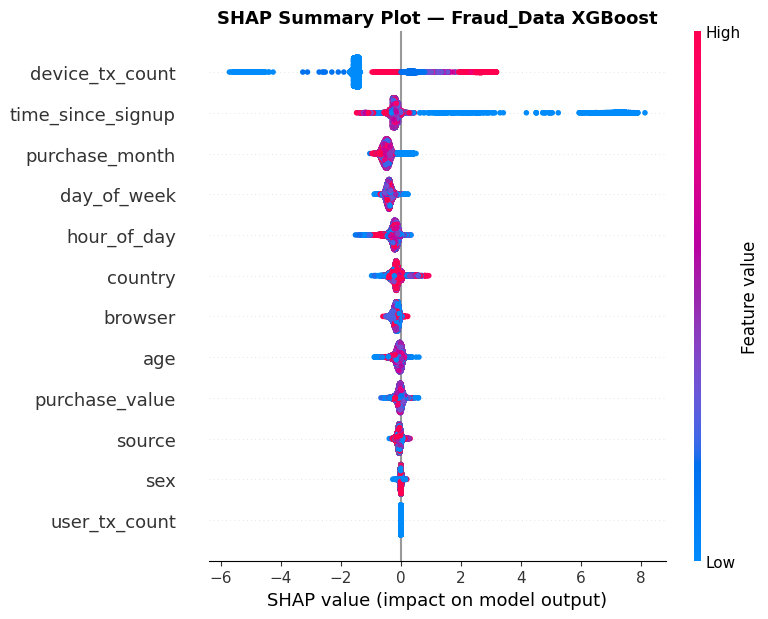

SHAP summary plot saved!


In [3]:
# SHAP explainer for fraud model
explainer_f = shap.TreeExplainer(xgb_f)
shap_values_f = explainer_f.shap_values(X_test_f_df)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_f, X_test_f_df, show=False)
plt.title('SHAP Summary Plot — Fraud_Data XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/shap_summary_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

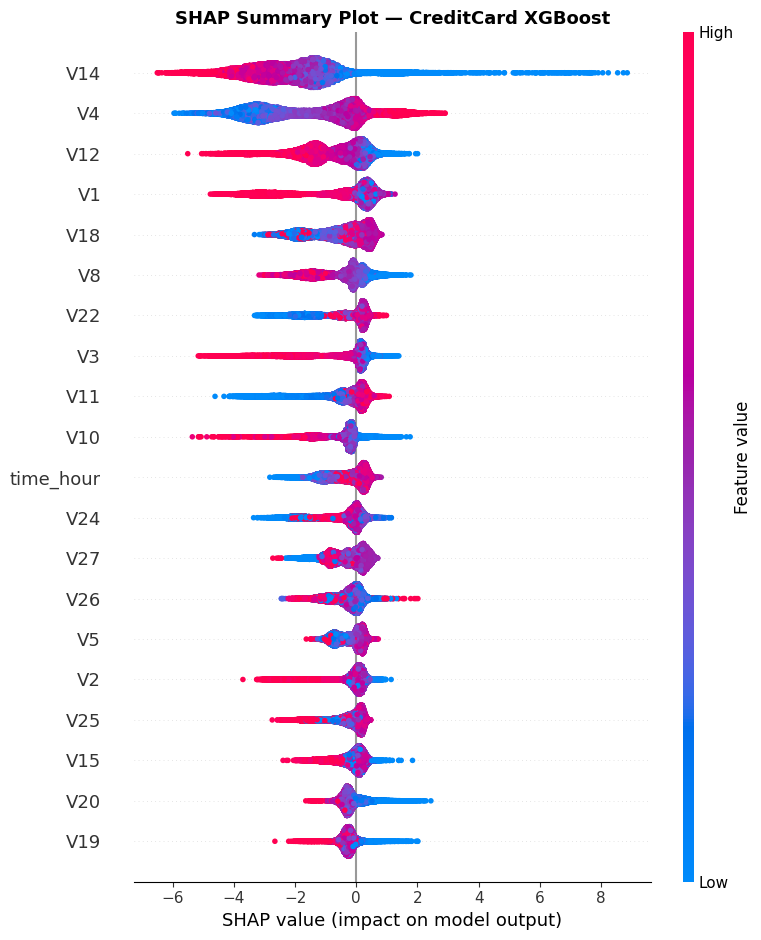

SHAP summary plot saved!


In [4]:
explainer_cc = shap.TreeExplainer(xgb_cc)
shap_values_cc = explainer_cc.shap_values(X_test_cc_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cc, X_test_cc_df, show=False)
plt.title('SHAP Summary Plot — CreditCard XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/shap_summary_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

True Positive index: 17
False Positive index: 3346
False Negative index: 2


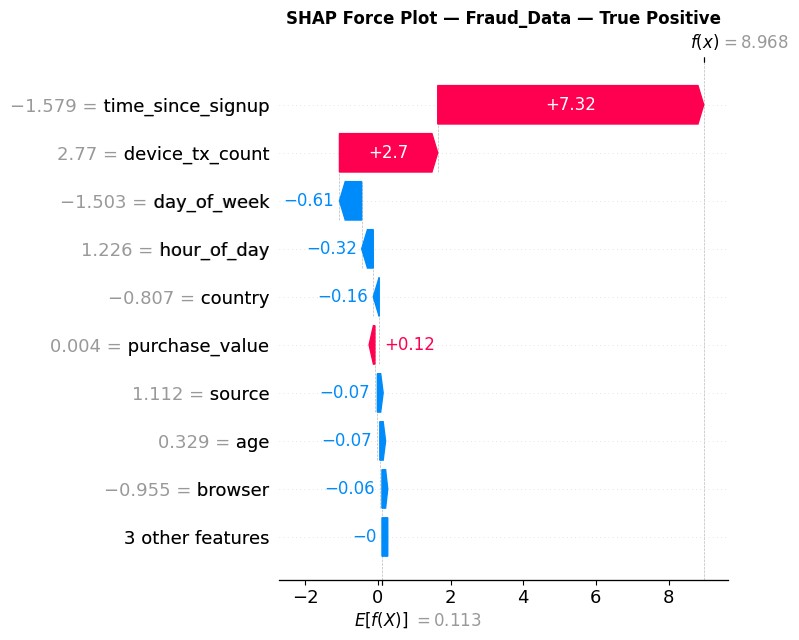

Saved: shap_force_fraud_true_positive.png


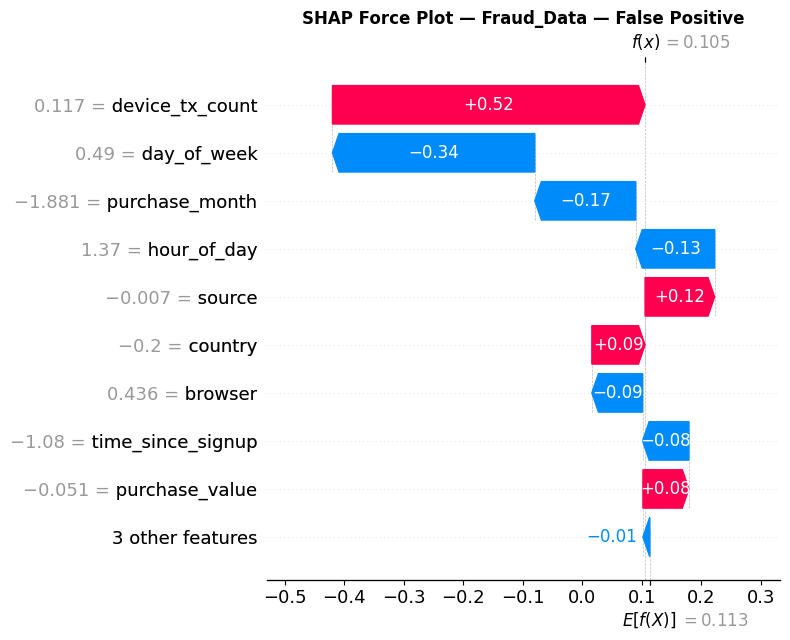

Saved: shap_force_fraud_false_positive.png


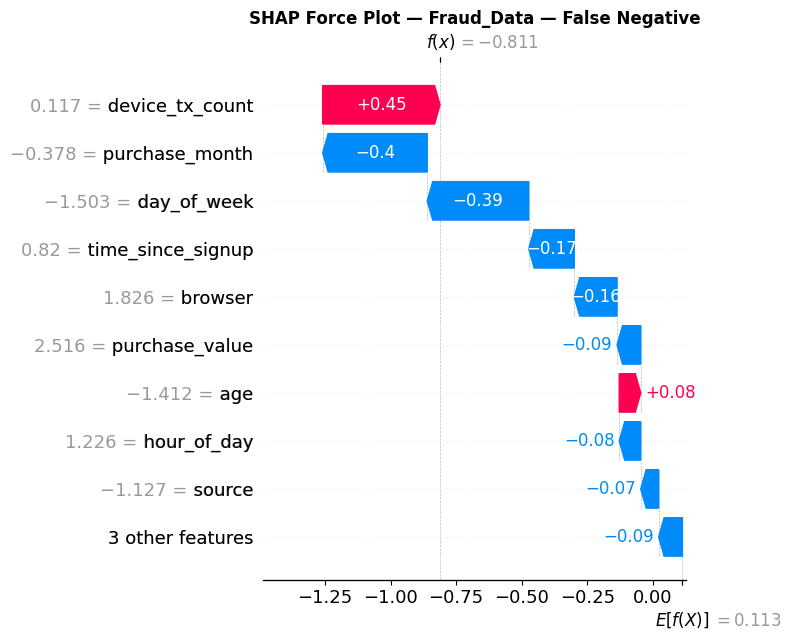

Saved: shap_force_fraud_false_negative.png


In [5]:
# Get predictions to find TP, FP, FN
y_pred_f = xgb_f.predict(X_test_f_df)
y_prob_f = xgb_f.predict_proba(X_test_f_df)[:,1]

# True Positive — actual fraud, predicted fraud
tp_idx = np.where((y_test_f.values == 1) & (y_pred_f == 1))[0][0]
# False Positive — actual legit, predicted fraud
fp_idx = np.where((y_test_f.values == 0) & (y_pred_f == 1))[0][0]
# False Negative — actual fraud, predicted legit
fn_idx = np.where((y_test_f.values == 1) & (y_pred_f == 0))[0][0]

print(f"True Positive index: {tp_idx}")
print(f"False Positive index: {fp_idx}")
print(f"False Negative index: {fn_idx}")

shap.initjs()

# Plot and save each
for idx, label in [(tp_idx, 'true_positive'), (fp_idx, 'false_positive'), (fn_idx, 'false_negative')]:
    fig, ax = plt.subplots(figsize=(16, 3))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_f[idx],
            base_values=explainer_f.expected_value,
            data=X_test_f_df.iloc[idx],
            feature_names=X_test_f_df.columns.tolist()
        ), show=False
    )
    plt.title(f'SHAP Force Plot — Fraud_Data — {label.replace("_"," ").title()}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'notebooks/shap_force_fraud_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_force_fraud_{label}.png")

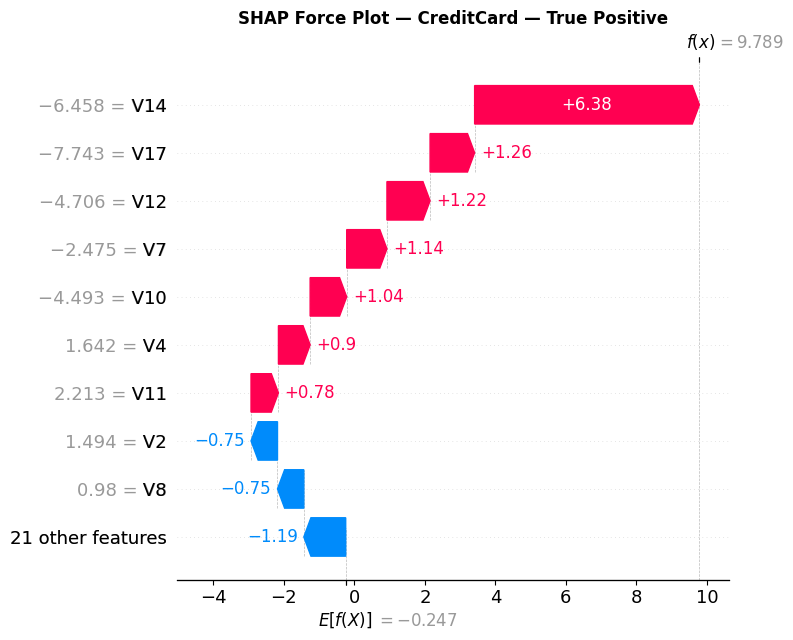

Saved: shap_force_cc_true_positive.png


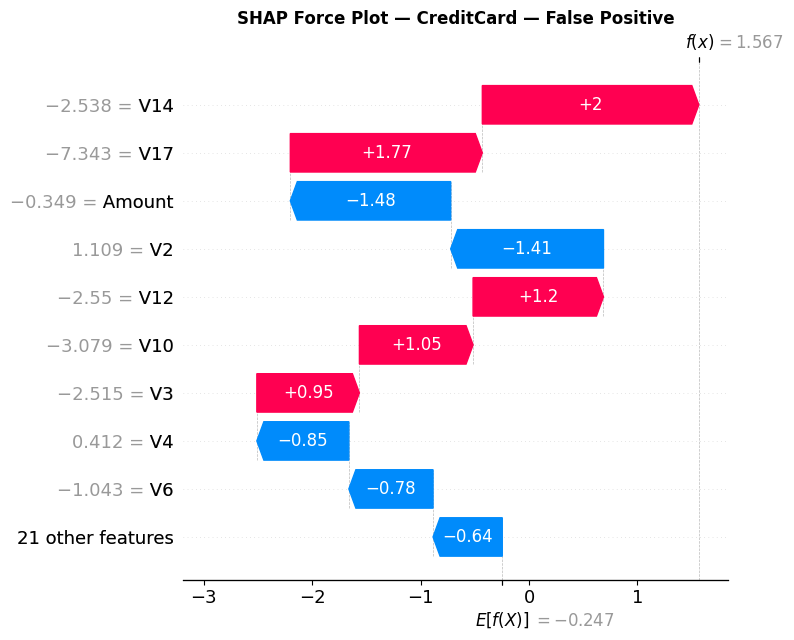

Saved: shap_force_cc_false_positive.png


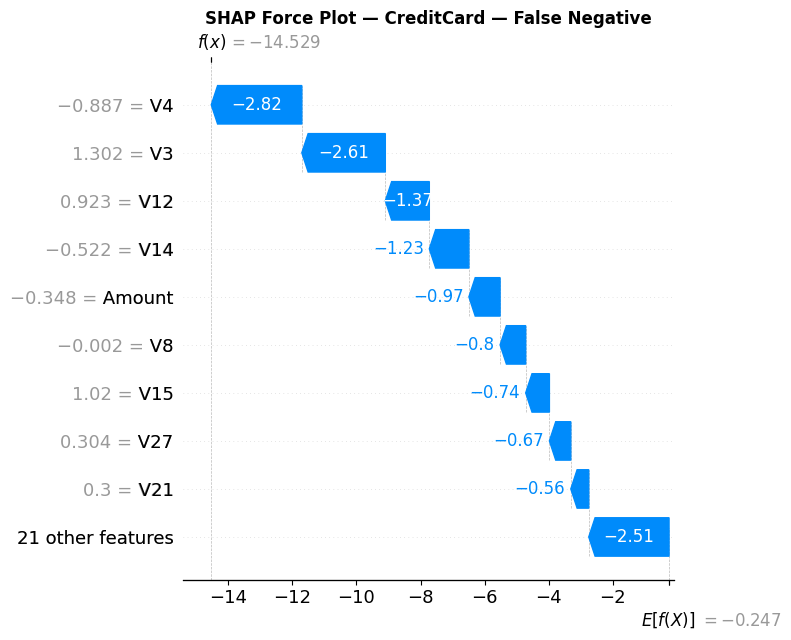

Saved: shap_force_cc_false_negative.png


In [6]:
y_pred_cc = xgb_cc.predict(X_test_cc_df)

tp_idx_cc = np.where((y_test_cc.values == 1) & (y_pred_cc == 1))[0][0]
fp_idx_cc = np.where((y_test_cc.values == 0) & (y_pred_cc == 1))[0][0]
fn_idx_cc = np.where((y_test_cc.values == 1) & (y_pred_cc == 0))[0][0]

for idx, label in [(tp_idx_cc, 'true_positive'), (fp_idx_cc, 'false_positive'), (fn_idx_cc, 'false_negative')]:
    fig, ax = plt.subplots(figsize=(16, 3))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_cc[idx],
            base_values=explainer_cc.expected_value,
            data=X_test_cc_df.iloc[idx],
            feature_names=X_test_cc_df.columns.tolist()
        ), show=False
    )
    plt.title(f'SHAP Force Plot — CreditCard — {label.replace("_"," ").title()}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'notebooks/shap_force_cc_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_force_cc_{label}.png")

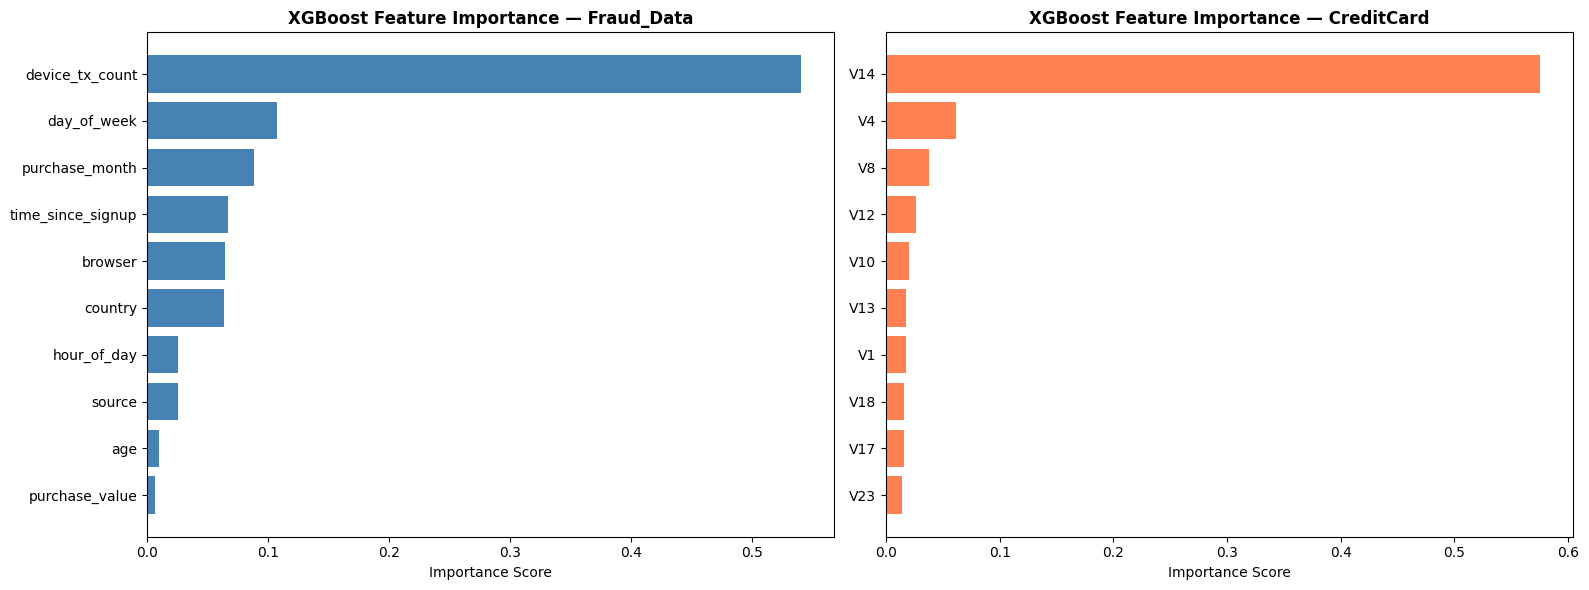

Feature importance plot saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud_Data built-in importance
feat_imp_f = pd.Series(xgb_f.feature_importances_,
                        index=X_fraud.columns).sort_values(ascending=False).head(10)
axes[0].barh(feat_imp_f.index[::-1], feat_imp_f.values[::-1], color='steelblue')
axes[0].set_title('XGBoost Feature Importance — Fraud_Data', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# CreditCard built-in importance
feat_imp_cc = pd.Series(xgb_cc.feature_importances_,
                         index=X_cc.columns).sort_values(ascending=False).head(10)
axes[1].barh(feat_imp_cc.index[::-1], feat_imp_cc.values[::-1], color='coral')
axes[1].set_title('XGBoost Feature Importance — CreditCard', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('notebooks/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")